In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
import snowflake.connector
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv('/Users/roelsomido/dbt_projects/.env')

try:
    conn = snowflake.connector.connect(
        user=os.getenv('SNOWFLAKE_USER'),
        password=os.getenv('SNOWFLAKE_PASSWORD'),
        account=os.getenv('SNOWFLAKE_ACCOUNT'),
        warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
        database=os.getenv('SNOWFLAKE_DATABASE'),
        schema=os.getenv('SNOWFLAKE_SCHEMA')
    )

    with conn.cursor() as cur:
        cur.execute("SELECT 1;")
        result = cur.fetchone()
        
    print("✅ Connection Successful! Verified with test query result:", result[0])

except snowflake.connector.errors.ProgrammingError as e:
    print(f"❌ Connection Failed! Please check your credentials or account details.\nError: {e}")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Connection Successful! Verified with test query result: 1


In [3]:
cur = conn.cursor()

# Move the semicolon to the very end
query = "SELECT * FROM RAW_DB.ECOM_SOURCE.MART_PRODUCT_SALES;"
cur.execute(query)

df = cur.fetch_pandas_all()
df.head()


,PRODUCT_ID,PRODUCT_KEY,PRODUCT_NAME,CATEGORY,SUBCATEGORY,PRODUCT_LINE,MAINTENANCE,PRODUCT_COST,TOTAL_ORDERS,TOTAL_UNITS_SOLD,TOTAL_REVENUE,AVG_LINE_REVENUE,FIRST_SALE_DATE,LAST_SALE_DATE,TOTAL_PROFIT
0,343,BK-R50B-52,Road-650 Black- 52,Bikes,Road Bikes,Road,True,487,89,89.0,66915.0,751.853933,2011-01-20,2012-12-19,23572.0
1,339,BK-R50B-44,Road-650 Black- 44,Bikes,Road Bikes,Road,True,487,63,63.0,47565.0,755.000000,2011-01-25,2012-12-26,16884.0
2,335,BK-R50B-60,Road-650 Black- 60,Bikes,Road Bikes,Road,True,487,76,76.0,57156.0,752.052632,2011-02-02,2012-12-12,20144.0
3,359,BK-M68B-38,Mountain-200 Black- 38,Bikes,Mountain Bikes,Mountain,True,1252,582,582.0,1294854.0,2224.835052,2011-12-29,2013-12-28,566190.0
4,591,BK-M18S-40,Mountain-500 Silver- 40,Bikes,Mountain Bikes,Mountain,True,308,45,45.0,25425.0,565.000000,2013-01-04,2013-12-26,11565.0


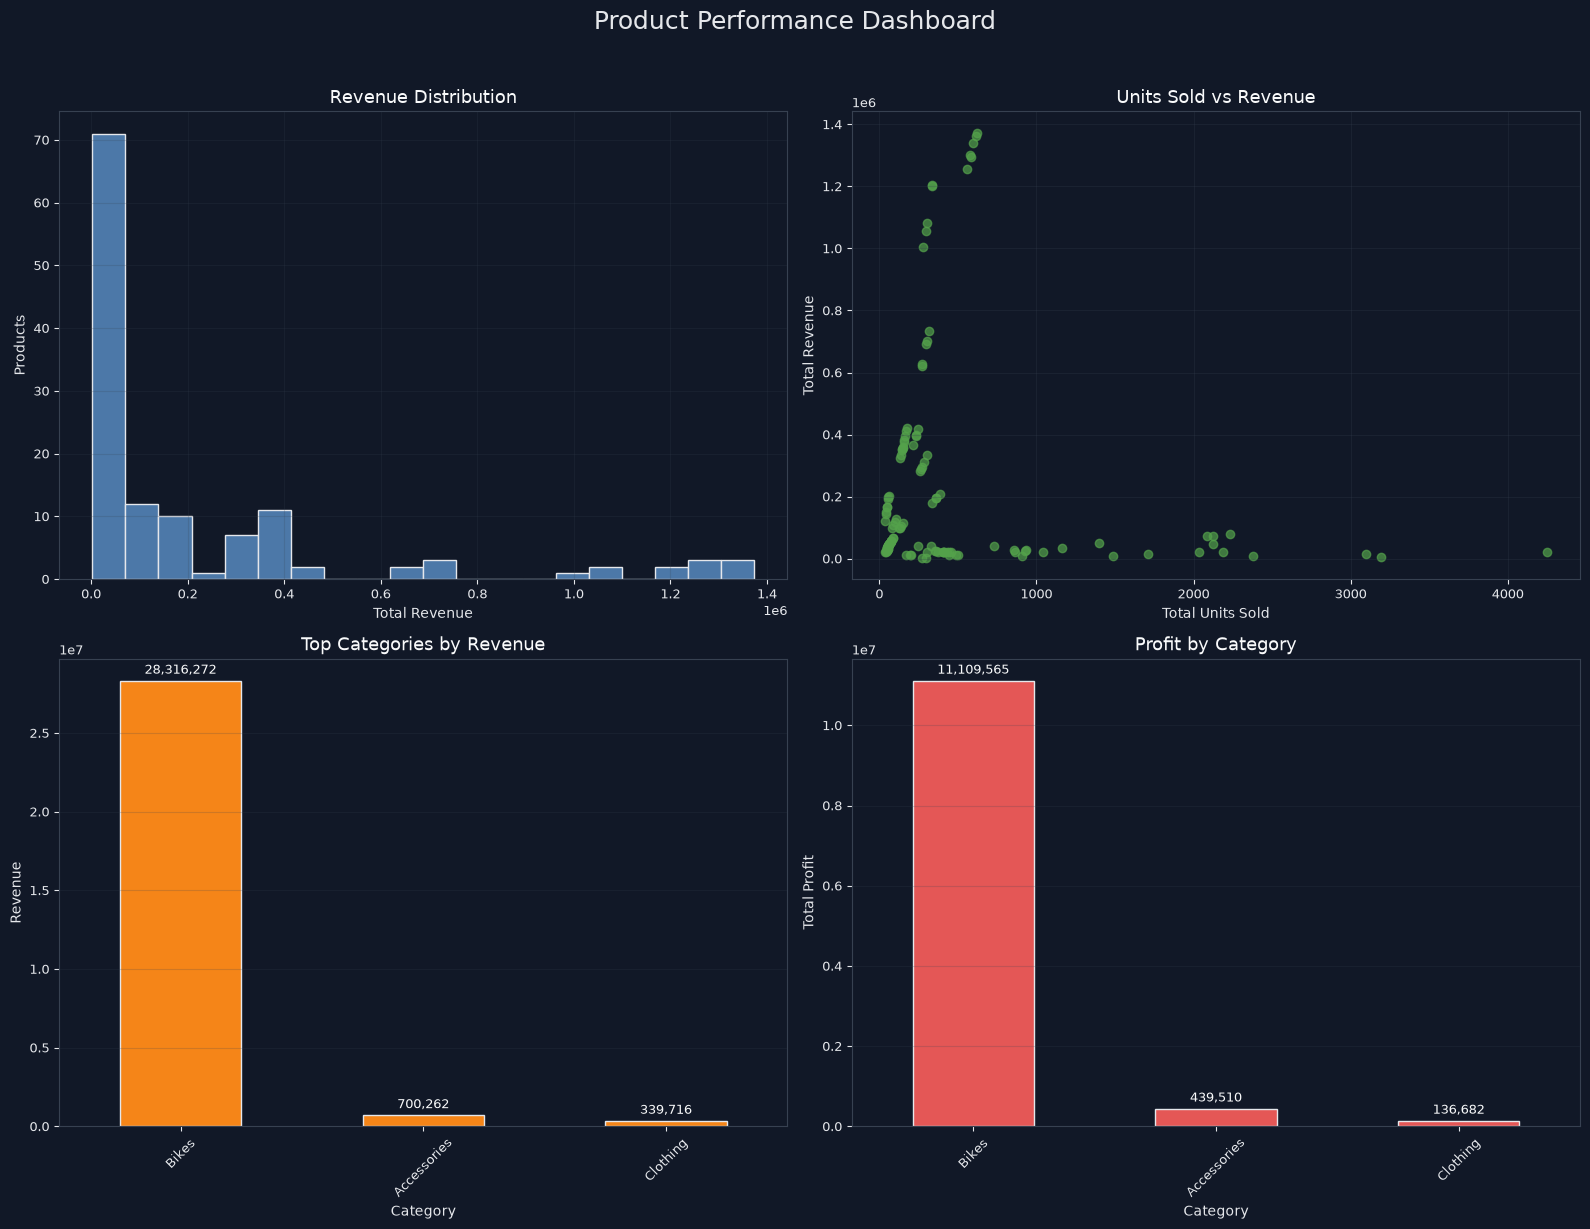

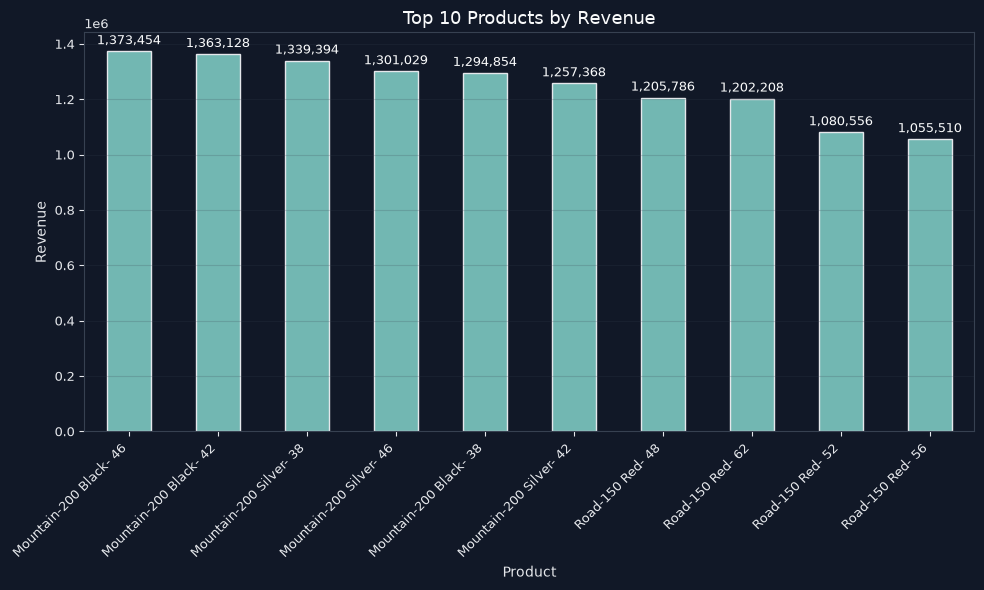

In [4]:
# Create a clean working dataframe for plotting
plot_df = df.copy()

for col in [
    "TOTAL_ORDERS",
    "TOTAL_UNITS_SOLD",
    "TOTAL_REVENUE",
    "AVG_LINE_REVENUE",
    "TOTAL_PROFIT",
    "PRODUCT_COST",
]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=["TOTAL_REVENUE", "TOTAL_UNITS_SOLD"]).copy()
plot_df["CATEGORY"] = (
    plot_df["CATEGORY"]
    .astype("string")
    .str.strip()
    .replace(["N/A", "n/a", "NA", "na", "NaN", "NULL", "null", "None", "none", ""], pd.NA)
)

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#111827",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#E5E7EB",
    "axes.titlecolor": "#F9FAFB",
    "xtick.color": "#E5E7EB",
    "ytick.color": "#E5E7EB",
    "text.color": "#E5E7EB",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": "sans-serif",
    "grid.color": "#374151",
})


def add_bar_labels(ax, prefix="", suffix=""):
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{prefix}{val:,.0f}{suffix}" for val in container.datavalues],
            padding=3,
            fontsize=9,
            color="#F9FAFB",
        )

# Prepare summary data for dashboard charts
category_revenue = (
    plot_df.dropna(subset=["CATEGORY"])
    .groupby("CATEGORY", dropna=True)["TOTAL_REVENUE"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_category = (
    plot_df.dropna(subset=["CATEGORY"])
    .groupby("CATEGORY", dropna=True)["TOTAL_PROFIT"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue = (
    plot_df.sort_values("TOTAL_REVENUE", ascending=False)
    .head(10)
    .set_index("PRODUCT_NAME")["TOTAL_REVENUE"]
)

# Compact 2x2 dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor="#111827")
fig.suptitle("Product Performance Dashboard", fontsize=18, y=1.02)

for ax in axes.flat:
    ax.set_facecolor("#111827")

# 1. Revenue distribution
axes[0, 0].hist(plot_df["TOTAL_REVENUE"], bins=20, color="#4C78A8", edgecolor="#E5E7EB")
axes[0, 0].set_title("Revenue Distribution")
axes[0, 0].set_xlabel("Total Revenue")
axes[0, 0].set_ylabel("Products")
axes[0, 0].grid(True, alpha=0.2)

# 2. Units sold vs revenue
axes[0, 1].scatter(plot_df["TOTAL_UNITS_SOLD"], plot_df["TOTAL_REVENUE"], alpha=0.7, color="#54A24B")
axes[0, 1].set_title("Units Sold vs Revenue")
axes[0, 1].set_xlabel("Total Units Sold")
axes[0, 1].set_ylabel("Total Revenue")
axes[0, 1].grid(True, alpha=0.25)

# 3. Top categories by revenue
category_revenue.head(10).plot(kind="bar", ax=axes[1, 0], color="#F58518", edgecolor="#E5E7EB")
axes[1, 0].set_title("Top Categories by Revenue")
axes[1, 0].set_xlabel("Category")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(True, axis="y", alpha=0.2)
add_bar_labels(axes[1, 0], suffix="")

# 4. Profit by category
profit_by_category.head(10).plot(kind="bar", ax=axes[1, 1], color="#E45756", edgecolor="#E5E7EB")
axes[1, 1].set_title("Profit by Category")
axes[1, 1].set_xlabel("Category")
axes[1, 1].set_ylabel("Total Profit")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(True, axis="y", alpha=0.2)
add_bar_labels(axes[1, 1], suffix="")

plt.tight_layout()
plt.show()

# Optional single chart for top products if you want more detail
plt.figure(figsize=(10, 6), facecolor="#111827")
product_revenue.plot(kind="bar", color="#72B7B2", edgecolor="#E5E7EB")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.2)
add_bar_labels(plt.gca(), suffix="")
plt.tight_layout()
plt.show()